# Google Drive Mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')
# mounting the google drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import All Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib inline
import seaborn as sns
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score , auc
from sklearn.model_selection import train_test_split

import cv2
#from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf # Added this line
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense,Conv2D , MaxPooling2D, Flatten,BatchNormalization,Dropout
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow_hub as hub

# Tomato_ leaf data set


In [ ]:
# downloaded the data set from the kaggle (Tomato data set )

import kagglehub
import os
import shutil
from tqdm.notebook import tqdm # Import tqdm for progress bar

# Download latest version of the dataset
# The dataset name 'ashishmotwani/tomato' is used as provided by the user's previous context.
path = kagglehub.dataset_download("ashishmotwani/tomato")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tomato' dataset.
Path to dataset files: /kaggle/input/tomato


In [ ]:

# Data set copied from the run time to the destined folder
destination_folder = '/content/drive/MyDrive/plant_disease_dataset/data_/Tomato_'

# Create the destination directory if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Copy the contents of the downloaded dataset to the Google Drive folder
# The 'path' variable from the previous cell contains the local directory where the dataset was downloaded.
# We copy the entire directory contents.
print(f"Copying dataset to: {destination_folder}")
for item in tqdm(os.listdir(path), desc="Copying files"):
    s = os.path.join(path, item)
    d = os.path.join(destination_folder, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print(f"Dataset copied to: {destination_folder}")

Copying dataset to: /content/drive/MyDrive/plant_disease_dataset/data_/Tomato_


Copying files:   0%|          | 0/2 [00:00<?, ?it/s]

Dataset copied to: /content/drive/MyDrive/plant_disease_dataset/data_/Tomato_


In [3]:
import os

# Define the base directory where the dataset was copied
base_dataset_path = '/content/drive/MyDrive/plant_disease_dataset/data_/Tomato_'

print(f"Checking contents of: {base_dataset_path}")

# List contents of the base dataset path (e.g., train, validation, test folders)
if os.path.exists(base_dataset_path):
    print(f"Contents found at {base_dataset_path}:")
    for item in os.listdir(base_dataset_path):
        item_path = os.path.join(base_dataset_path, item)
        print(f"- {item} {'(Directory)' if os.path.isdir(item_path) else '(File)'}")
else:
    print(f"Base dataset path does not exist: {base_dataset_path}")


Checking contents of: /content/drive/MyDrive/plant_disease_dataset/data_/Tomato_
Contents found at /content/drive/MyDrive/plant_disease_dataset/data_/Tomato_:
- train (Directory)
- valid (Directory)


In [4]:
import os

# Assuming the main data is in a 'train' subdirectory, as is common for these datasets
# Adjust 'train_dir' if your structure is different (e.g., 'data' or directly class folders)
train_dir = os.path.join(base_dataset_path, 'train') # Assuming 'train' is the directory with class folders


print(f"Folders in '{train_dir}':")

# List all entries in the train_dir
for item in os.listdir(train_dir):
    item_path = os.path.join(train_dir, item)
    # Check if the item is a directory (a class folder)
    if os.path.isdir(item_path):
        print(f"- {item}")


Folders in '/content/drive/MyDrive/plant_disease_dataset/data_/Tomato_/train':
- Septoria_leaf_spot
- powdery_mildew
- Tomato_mosaic_virus
- Bacterial_spot
- Early_blight
- Late_blight
- Leaf_Mold
- Spider_mites Two-spotted_spider_mite
- Tomato_Yellow_Leaf_Curl_Virus
- healthy
- Target_Spot


In [5]:
import os

# Assuming the main data is in a 'train' subdirectory, as is common for these datasets
# Adjust 'train_dir' if your structure is different (e.g., 'data' or directly class folders)
train_dir = os.path.join(base_dataset_path, 'train') # Assuming 'train' is the directory with class folders

if os.path.exists(train_dir):
    print(f"\nCounting files in each class directory within: {train_dir}")
    class_counts = {}
    for class_name in os.listdir(train_dir):
        class_path = os.path.join(train_dir, class_name)
        if os.path.isdir(class_path):
            # Count only image files (e.g., .jpg, .jpeg, .png)
            num_files = len([name for name in os.listdir(class_path) if name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))])
            class_counts[class_name] = num_files

    # Sort for consistent output
    sorted_class_counts = sorted(class_counts.items())

    for class_name, count in sorted_class_counts:
        print(f"{class_name}: {count} files")
else:
    print(f"The directory '{train_dir}' does not exist. Please check the dataset structure.")


Counting files in each class directory within: /content/drive/MyDrive/plant_disease_dataset/data_/Tomato_/train
Bacterial_spot: 2826 files
Early_blight: 2455 files
Late_blight: 3113 files
Leaf_Mold: 2754 files
Septoria_leaf_spot: 2882 files
Spider_mites Two-spotted_spider_mite: 1747 files
Target_Spot: 1827 files
Tomato_Yellow_Leaf_Curl_Virus: 2039 files
Tomato_mosaic_virus: 2153 files
healthy: 3051 files
powdery_mildew: 1004 files


# Data Set verified matched with the actual data sets

In [6]:
import os

def count_files_and_extensions(directory):
    total_files = 0
    extension_counts = {}

    for root, _, files in os.walk(directory):
        for file in files:
            total_files += 1
            ext = os.path.splitext(file)[1].lower()
            extension_counts[ext] = extension_counts.get(ext, 0) + 1

    return total_files, extension_counts

# Assuming base_dataset_path is already defined from previous cells
# base_dataset_path = '/content/drive/MyDrive/plant_disease_dataset/data_/Tomato_'

if 'base_dataset_path' in locals() and os.path.exists(base_dataset_path):
    total, extensions = count_files_and_extensions(base_dataset_path)
    print(f"Total files in dataset: {total}")
    print("File extension breakdown:")
    for ext, count in sorted(extensions.items()):
        print(f"  {ext}: {count}")
else:
    print(f"Base dataset path '{base_dataset_path}' not found or not defined.")

Total files in dataset: 32534
File extension breakdown:
  .jpeg: 4
  .jpg: 32025
  .png: 505


# Train Image Data Preprocessing

### Efficient Image Loading with `image_dataset_from_directory`

For large datasets, loading all images into memory at once can be inefficient and lead to memory errors. TensorFlow's `tf.keras.utils.image_dataset_from_directory` provides a highly optimized way to load image data directly from a directory structure.

Key benefits:
-   **Memory Efficiency**: It loads images in batches, so only a subset of data is in memory at any given time.
-   **Preprocessing**: It can handle basic preprocessing like resizing and color mode conversion.
-   **Automatic Labeling**: It automatically infers class labels from the subdirectory names.
-   **Dataset Splitting**: Easily split your dataset into training and validation subsets.

We will use this function to create `tf.data.Dataset` objects for our training and (optional) validation data. These datasets are highly optimized for training deep learning models.

In [4]:
import shutil
import os
import tensorflow as tf

# 1. Define paths
drive_train_dir = '/content/drive/MyDrive/plant_disease_dataset/data_/Tomato_/train'
drive_valid_dir = '/content/drive/MyDrive/plant_disease_dataset/data_/Tomato_/valid'

local_train_dir = '/content/local_data/train'
local_valid_dir = '/content/local_data/valid'

# 2. Copy from Drive to Local Runtime
def sync_local_data(src, dst):
    if os.path.exists(src):
        if not os.path.exists(dst):
            print(f"Copying {src} to local runtime...")
            shutil.copytree(src, dst)
        else:
            print(f"Local data already exists at {dst}")

sync_local_data(drive_train_dir, local_train_dir)
sync_local_data(drive_valid_dir, local_valid_dir)

# 3. Create datasets
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    local_train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    local_valid_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

# 4. Optimization
# We removed .cache() to prevent RAM exhaustion (OOM crashes).
# The data is already on the local disk, so it will still be fast!
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print(f"Ready to train with {len(class_names)} classes without memory caching.")

Local data already exists at /content/local_data/train
Local data already exists at /content/local_data/valid
Found 25851 files belonging to 11 classes.
Found 6683 files belonging to 11 classes.
Ready to train with 11 classes without memory caching.


In [5]:
import os
# 1. Verify Local Dataset Integrity
def verify_local_paths(path):
    if os.path.exists(path):
        total = sum([len(files) for r, d, files in os.walk(path)])
        print(f"✅ {path} verified. Total files: {total}")
    else:
        print(f"❌ {path} not found!")

verify_local_paths(local_train_dir)
verify_local_paths(local_valid_dir)

# 2. Confirm T4 GPU Initialization
print("\n--- GPU Status ---")
!nvidia-smi

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\nTensorFlow is using GPU: {gpus[0]}")
else:
    print("\nTensorFlow is NOT using a GPU. Please go to Runtime -> Change runtime type -> Hardware accelerator and select T4 GPU.")

✅ /content/local_data/train verified. Total files: 25851
✅ /content/local_data/valid verified. Total files: 6683

--- GPU Status ---
Wed Jul 22 08:39:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             25W /   70W |     107MiB /  15360MiB |      0%      Default |
|      

In [ ]:
import matplotlib.pyplot as plt

# Let's visualize a batch of images and their labels from the training dataset

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # Take one batch
    for i in range(min(9, len(images))): # Display up to 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Image visualization started


In [6]:
# Update BATCH_SIZE and EPOCHS based on the user's provided code
BATCH_SIZE = 64
EPOCHS = 15

# Define image parameters for the model
IMAGE_SIZE = 224 # Using IMG_HEIGHT/IMG_WIDTH from previous cells
CHANNELS = 3

# Define the input shape for the model, including batch size
input_shape=(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

print(f"Updated BATCH_SIZE: {BATCH_SIZE}")
print(f"Updated EPOCHS: {EPOCHS}")
print(f"Model input_shape: {input_shape}")

Updated BATCH_SIZE: 64
Updated EPOCHS: 15
Model input_shape: (64, 224, 224, 3)


### Preprocessing and Data Augmentation Layers

These layers will be part of the model pipeline to handle resizing, rescaling pixel values, and applying data augmentation on the fly during training. This helps the model generalize better and reduces overfitting.

In [7]:
# Define resizing and rescaling layer
resizing_and_rescaling = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1./255)
])

# Define data augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

print("Preprocessing layers defined: resizing_and_rescaling, data_augmentation")

Preprocessing layers defined: resizing_and_rescaling, data_augmentation


In [ ]:
# Let's visualize a batch of images and their labels from the training dataset

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # Take one batch
    for i in range(min(9, len(images))): # Display up to 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [8]:

print(f"Number of batches in training dataset: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of images in training dataset: {tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE}")

if val_ds is not None:
    print(f"Number of batches in validation dataset: {tf.data.experimental.cardinality(val_ds).numpy()}")
    print(f"Number of images in validation dataset: {tf.data.experimental.cardinality(val_ds).numpy() * BATCH_SIZE}")
else:
    print("No validation dataset created.")

print(f"Class names: {class_names}")

Number of batches in training dataset: 404
Number of images in training dataset: 25856
Number of batches in validation dataset: 105
Number of images in validation dataset: 6720
Class names: ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']


In [ ]:
# The variables 'image_data' and 'image_label' are no longer defined,
# as we have switched to using `tf.keras.utils.image_dataset_from_directory`.
# This function creates `tf.data.Dataset` objects (`train_ds` and `val_ds`)
# which are optimized for batch processing during model training.
# Converting them to single NumPy arrays like `x_train` and `y_train`
# would negate the memory efficiency benefits for large datasets.
# You will typically use `train_ds` and `val_ds` directly when training your model.

### Build and Train a Simple CNN Model

Now that you have your data loaded efficiently using `tf.data.Dataset` objects (`train_ds` and `val_ds`), you can build and train a deep learning model. Here's an example of a simple Convolutional Neural Network (CNN) using Keras.

In [32]:
num_classes = len(class_names)

model = tf.keras.models.Sequential([
  resizing_and_rescaling,
  data_augmentation,
  # Convolution layer 1
  tf.keras.layers.Conv2D(filters=120, kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
  tf.keras.layers.MaxPool2D(pool_size=(2,2)),
  # Convolution layer 2
  tf.keras.layers.Conv2D(filters=100, kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'),
  tf.keras.layers.MaxPool2D(pool_size=(2,2)),
  # Convolution layer 3
  tf.keras.layers.Conv2D(filters=80, kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'),
  tf.keras.layers.MaxPool2D(pool_size=(2,2)),
  # Convolution layer 4
  tf.keras.layers.Conv2D(filters=60, kernel_size=(3,3),strides=(1,1),padding='same',activation='relu'),
  tf.keras.layers.MaxPool2D(pool_size=(2,2)),

  # Flatten Layers
  tf.keras.layers.Flatten(),

  # Dense layers
  tf.keras.layers.Dense(units=1000,activation='relu'),
  tf.keras.layers.Dropout(0.4),
  tf.keras.layers.Dense(units=500,activation='relu'),
  tf.keras.layers.Dropout(0.3),
  tf.keras.layers.Dense(units=100,activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(units=num_classes,activation='softmax') # Use num_classes here
])

model.build(input_shape=input_shape) # Explicitly build the model with the defined input_shape
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (64, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (64, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (64, 224, 224, 120)    │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (64, 112, 112, 120)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (64, 112, 112, 100)    │       108,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (64, 56, 56, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (64, 56, 56, 80)       │        72,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (64, 28, 28, 80)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (64, 28, 28, 60)       │        43,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (64, 14, 14, 60)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (64, 11760)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (64, 1000)             │    11,761,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (64, 1000)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (64, 500)              │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (64, 500)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (64, 100)              │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (64, 100)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (64, 11)               │         1,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,539,511 (47.83 MB)

 Trainable params: 12,539,511 (47.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# This cell contained a duplicate model compilation. It has been replaced by the next compile cell.

In [10]:
# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # Use from_logits=False because our last layer has softmax activation
    metrics=['accuracy']
)

In [ ]:
# This cell contained a duplicate model training. It has been replaced by the next fit cell.

In [11]:
import os
import tensorflow as tf
from tqdm.keras import TqdmCallback

# Check for GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('Warning: GPU device not found. Training will be very slow.')
else:
  print('Found GPU at: {}'.format(device_name))

# 1. Paths
models_dir = '/content/drive/MyDrive/plant_disease_dataset/models_'
os.makedirs(models_dir, exist_ok=True)
checkpoint_path = os.path.join(models_dir, 'tomato_model_best.weights.h5')

# 2. Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

# 3. Resume Weights
if os.path.exists(checkpoint_path):
    try:
        model.load_weights(checkpoint_path)
        print("Weights loaded successfully.")
    except Exception as e:
        print(f"Could not load weights: {e}")

# 4. Training
print("Starting training... (Note: The first epoch might take a few minutes to start while data is cached from Drive)")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=0, # Set to 0 to avoid double output with TqdmCallback
    callbacks=[
        early_stopping,
        model_checkpoint,
        TqdmCallback(verbose=1)
    ]
)

Found GPU at: /device:GPU:0
Starting training... (Note: The first epoch might take a few minutes to start while data is cached from Drive)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]


Epoch 1: val_loss improved from None to 1.59753, saving model to /content/drive/MyDrive/plant_disease_dataset/models_/tomato_model_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/plant_disease_dataset/models_/tomato_model_best.weights.h5

Epoch 2: val_loss improved from 1.59753 to 0.83379, saving model to /content/drive/MyDrive/plant_disease_dataset/models_/tomato_model_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/plant_disease_dataset/models_/tomato_model_best.weights.h5

Epoch 3: val_loss improved from 0.83379 to 0.81114, saving model to /content/drive/MyDrive/plant_disease_dataset/models_/tomato_model_best.weights.h5

Epoch 3: finished saving model to /content/drive/MyDrive/plant_disease_dataset/models_/tomato_model_best.weights.h5

Epoch 4: val_loss improved from 0.81114 to 0.54168, saving model to /content/drive/MyDrive/plant_disease_dataset/models_/tomato_model_best.weights.h5

Epoch 4: finished saving model to /content/driv

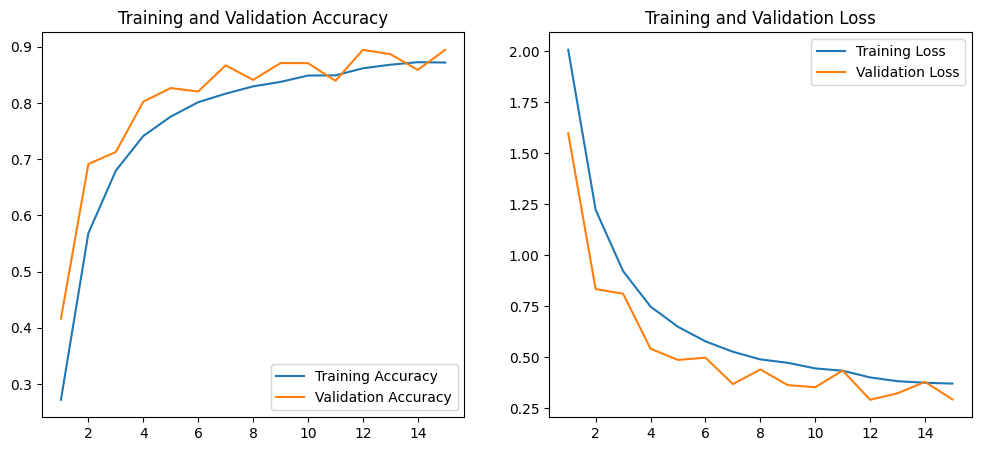

In [12]:
import matplotlib.pyplot as plt

# 1. Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

Evaluating model performance...
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step

Classification Report:
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.86      0.88      0.87       732
                        Early_blight       0.87      0.87      0.87       643
                         Late_blight       0.85      0.82      0.83       792
                           Leaf_Mold       0.93      0.87      0.90       739
                  Septoria_leaf_spot       0.80      0.82      0.81       746
Spider_mites Two-spotted_spider_mite       0.92      0.97      0.94       435
                         Target_Spot       0.93      0.93      0.93       457
       Tomato_Yellow_Leaf_Curl_Virus       0.95      0.95      0.95       498
                 Tomato_mosaic_virus       0.98      0.96      0.97       584
                             healthy       0.98      0.96      0.97       805
                      powdery_mildew     

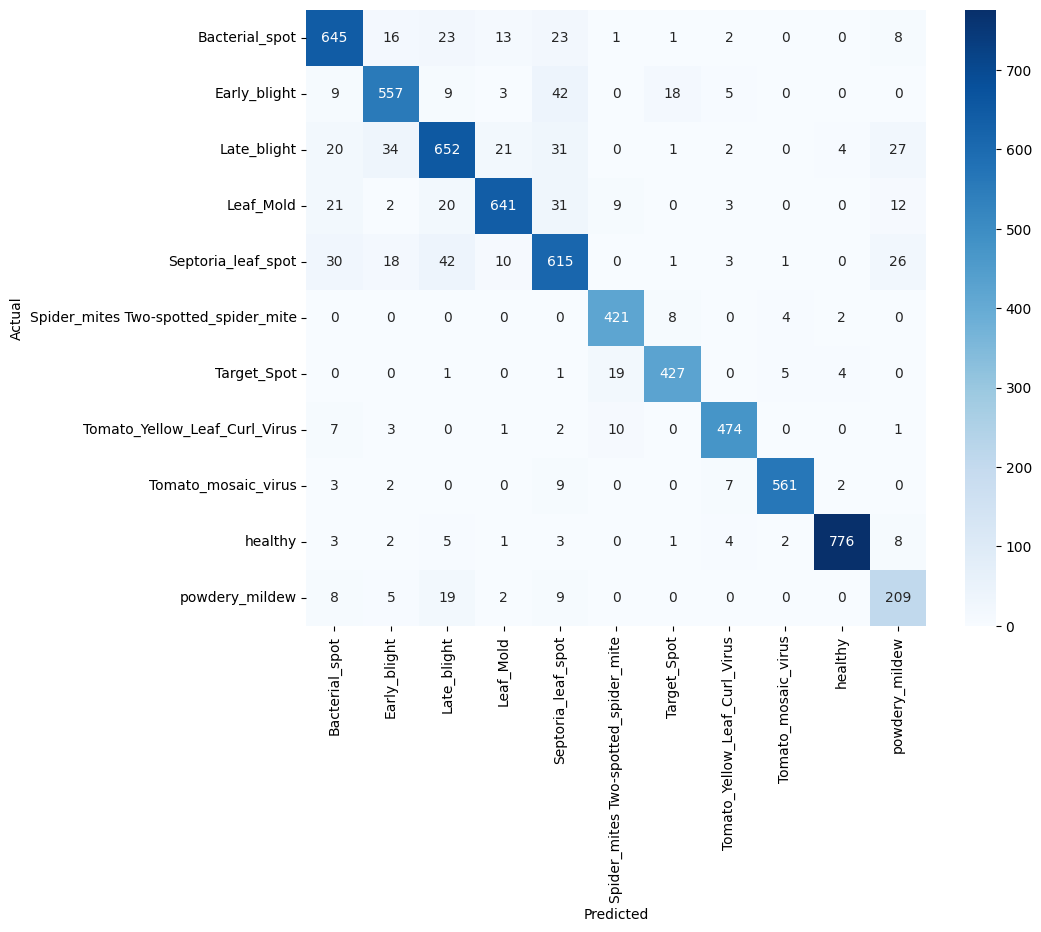

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 2. Detailed Evaluation
print("Evaluating model performance...")
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Extract true labels from val_ds
y_true = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# WEED DATASET


```
# This is formatted as code
```



# Grad Cam Visualizations

In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# 1. Define the path to your saved weights
checkpoint_path = r'/content/drive/MyDrive/plant_disease_dataset/models_/tomato_model_best.weights.h5'

# 2. Re-initialize your model architecture (Run the cell where you defined your Sequential model)
# model = tf.keras.models.Sequential([...])
# model.build(input_shape=input_shape)

# 3. Load the trained weights into the architecture
model.load_weights(checkpoint_path)
print("Trained weights successfully loaded into the model!")

Trained weights successfully loaded into the model!


In [39]:
def get_img_array(img_path, size):
    # Load image and convert to array
    img = tf.keras.utils.load_img(img_path, target_size=size)
    array = tf.keras.utils.img_to_array(img)
    # Expand dimensions to match batch format: (1, 224, 224, 3)
    array = np.expand_dims(array, axis=0)
    return array

def make_gradcam_heatmap(img_array, model):
    # 1. Ensure the model has been built/called so tensors are defined
    if not model.built:
        model.build(input_shape=(None, 224, 224, 3))

    # 2. Find the last Conv2D layer
    last_conv_layer_name = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)][-1]
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # 3. Create a sub-model. Using model.input (singular) specifically for Sequential models
    grad_model = tf.keras.models.Model(
        [model.input], [last_conv_layer.output, model.output]
    )

    # 4. Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 5. Calculate gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 6. Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Weighted sum of feature map channels
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. ReLU and Normalization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy(), pred_index.numpy()

In [57]:
def make_gradcam_heatmap_static(img_array, model):
    # 1. Prepare the full batch (64 images)
    dummy_batch = np.zeros((63, 224, 224, 3), dtype=np.float32)
    full_batch = np.vstack([img_array, dummy_batch])
    full_batch = tf.cast(full_batch, tf.float32)

    # 2. Identify the target convolutional layer
    conv_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
    target_layer = conv_layers[-1]

    # 3. Use GradientTape to track the forward pass manually
    # This bypasses the 'layer never called' error by calling them right here
    with tf.GradientTape() as tape:
        x = full_batch
        last_conv_output = None

        # Manually pass input through each layer until the end
        for layer in model.layers:
            x = layer(x)
            if layer == target_layer:
                last_conv_output = x
                # Ensure we watch the activations
                tape.watch(last_conv_output)

        preds = x
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Compute gradients
    grads = tape.gradient(class_channel, last_conv_output)

    # 5. Process the heatmap (first image in batch only)
    pooled_grads = tf.reduce_mean(grads[0], axis=(0, 1))
    conv_output_0 = last_conv_output[0]

    heatmap = conv_output_0 @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy(), pred_index.numpy()

Generating Grad-CAM heatmap via manual forward pass...


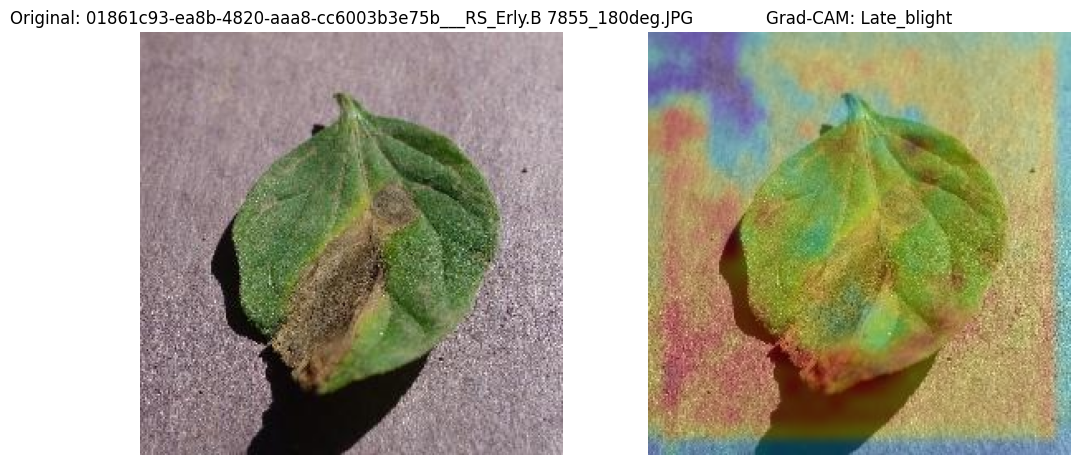

In [59]:
def save_and_display_gradcam(img_path, heatmap, class_names, pred_idx, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original: {os.path.basename(img_path)}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {class_names[pred_idx]}")
    plt.axis("off")
    plt.show()

# --- EXECUTION ---
test_image_path = r'/content/local_data/train/Early_blight/01861c93-ea8b-4820-aaa8-cc6003b3e75b___RS_Erly.B 7855_180deg.JPG'

img_array = get_img_array(test_image_path, size=(224, 224))

print("Generating Grad-CAM heatmap via manual forward pass...")
try:
    heatmap, pred_idx = make_gradcam_heatmap_static(img_array, model)
    save_and_display_gradcam(test_image_path, heatmap, class_names, pred_idx)
except Exception as e:
    import traceback
    print(f"Error: {e}")
    traceback.print_exc()

In [38]:
print(f"The final layer in the model is: {model.layers[-1].name}")

# Also, let's list all layer names to find the exact convolutional layer name you need
print("\nAll layer names in the current model:")
for layer in model.layers:
    print(layer.name)

The final layer in the model is: dense_7

All layer names in the current model:
sequential
sequential_1
conv2d_4
max_pooling2d_12
conv2d_5
max_pooling2d_13
conv2d_6
max_pooling2d_14
conv2d_7
max_pooling2d_15
flatten_3
dense_4
dropout_9
dense_5
dropout_10
dense_6
dropout_11
dense_7


In [47]:
for i, layer in enumerate(model.layers):
    config = layer.get_config()
    # Look for 'batch_input_shape' or 'batch_shape' in the config
    input_info = {k: v for k, v in config.items() if 'shape' in k}
    print(f"Layer {i} ({layer.name}): {input_info}")

Layer 0 (sequential): {'build_input_shape': (64, 224, 224, 3)}
Layer 1 (sequential_1): {'build_input_shape': (64, 224, 224, 3)}
Layer 2 (conv2d_12): {}
Layer 3 (max_pooling2d_20): {}
Layer 4 (conv2d_13): {}
Layer 5 (max_pooling2d_21): {}
Layer 6 (conv2d_14): {}
Layer 7 (max_pooling2d_22): {}
Layer 8 (conv2d_15): {}
Layer 9 (max_pooling2d_23): {}
Layer 10 (flatten_5): {}
Layer 11 (dense_12): {}
Layer 12 (dropout_15): {'noise_shape': None}
Layer 13 (dense_13): {}
Layer 14 (dropout_16): {'noise_shape': None}
Layer 15 (dense_14): {}
Layer 16 (dropout_17): {'noise_shape': None}
Layer 17 (dense_15): {}


In [48]:
print("--- data_augmentation configuration ---")
print(f"Is built: {data_augmentation.built}")
if hasattr(data_augmentation, 'input_shape'):
    print(f"Input shape: {data_augmentation.input_shape}")

for i, layer in enumerate(data_augmentation.layers):
    config = layer.get_config()
    input_info = {k: v for k, v in config.items() if 'shape' in k}
    print(f"Layer {i} ({layer.name}): {input_info}")

--- data_augmentation configuration ---
Is built: True
Input shape: (64, 224, 224, 3)
Layer 0 (random_flip): {}
Layer 1 (random_rotation): {}
Layer 2 (random_zoom): {}
Layer 3 (random_contrast): {}
